# 10. Đánh giá và so sánh mô hình

Notebook này thực hiện đánh giá cuối cùng các mô hình dự báo CPI nhóm Giao thông trên tập Test từ **01/2022 đến 12/2024**.

Các mô hình được so sánh gồm:

- Naive
- ElasticNet
- ARIMAX
- Ensemble

Các chỉ số đánh giá gồm **R², MAE, RMSE, MAPE và Directional Accuracy (DA)**.

In [1]:
import pandas as pd
import numpy as np

pred_df = pd.read_csv(
    "d:/HK3 - năm 3/Đồ Án/Code/vietnam-transportation-cpi-forecasting/data/processed/model_predictions.csv"
)

pred_df["MonthYear"] = pd.to_datetime(
    pred_df["MonthYear"]
).dt.to_period("M")

print("Kích thước:", pred_df.shape)

pred_df.head()

Kích thước: (36, 6)


,MonthYear,Actual,Naive_Pred,ElasticNet_Pred,ARIMAX_Pred,Ensemble_Pred
0,2022-01,1.18,-1.71,-1.453735,-1.559568,-1.505498
1,2022-02,2.35,1.18,2.129520,1.346587,1.746583
2,2022-03,4.80,2.35,1.945828,1.453298,1.704929
3,2022-04,-0.59,4.80,3.661777,2.729064,3.205582
4,2022-05,2.34,-0.59,-1.386979,-2.345179,-1.855640


## 2. Tính các chỉ số đánh giá

Các mô hình được đánh giá trên cùng tập Test 2022–2024 bằng các chỉ số:

- **MAE:** sai số tuyệt đối trung bình, càng thấp càng tốt.
- **RMSE:** nhấn mạnh các sai số lớn, càng thấp càng tốt.
- **R²:** mức độ giải thích biến động của CPI, càng cao càng tốt.
- **MAPE:** sai số phần trăm tuyệt đối trung bình.
- **DA:** tỷ lệ dự báo đúng chiều tăng hoặc giảm của CPI, càng cao càng tốt.

Do CPI có thể nhận giá trị gần 0 hoặc âm, MAPE có thể trở nên rất lớn và cần được diễn giải thận trọng.

In [2]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model_cols = {
    "Naive": "Naive_Pred",
    "ElasticNet": "ElasticNet_Pred",
    "ARIMAX": "ARIMAX_Pred",
    "Ensemble": "Ensemble_Pred"
}

actual = pred_df["Actual"]

evaluation_results = []

for model_name, pred_col in model_cols.items():

    pred = pred_df[pred_col]

    # MAE
    mae = mean_absolute_error(
        actual,
        pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    # R²
    r2 = r2_score(
        actual,
        pred
    )

    # MAPE
    # Bỏ đúng các quan sát Actual = 0 để tránh chia cho 0
    non_zero = actual != 0

    mape = (
        np.mean(
            np.abs(
                (actual[non_zero] - pred[non_zero])
                / actual[non_zero]
            )
        ) * 100
    )

    # Directional Accuracy
    da = (
        np.mean(
            np.sign(actual) == np.sign(pred)
        ) * 100
    )

    evaluation_results.append({
        "Model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "DA (%)": da
    })

evaluation_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

evaluation_df.round(4)

,Model,R2,MAE,RMSE,MAPE (%),DA (%)
0,Ensemble,-0.0690,1.9453,2.3332,440.1936,47.2222
1,ElasticNet,-0.0730,1.9421,2.3375,430.8424,50.0000
2,ARIMAX,-0.1205,2.0428,2.3887,544.9922,47.2222
3,Naive,-0.7292,2.5511,2.9675,981.8441,41.6667


### Nhận xét

Trên tập Test 2022–2024, **Ensemble có RMSE thấp nhất (2,3332)** và R² tốt nhất trong các mô hình, trong khi **ElasticNet có MAE thấp nhất (1,9421)** và DA cao nhất (**50%**). Tuy nhiên, chênh lệch RMSE giữa Ensemble và ElasticNet rất nhỏ, cho thấy hai mô hình có hiệu quả dự báo tương đối tương đương.

Cả bốn mô hình đều có R² âm, cho thấy khả năng giải thích biến động CPI trong giai đoạn Test còn hạn chế. Dù vậy, ElasticNet, ARIMAX và Ensemble đều cải thiện đáng kể RMSE so với mô hình Naive.

MAPE có giá trị rất cao do CPI chứa nhiều quan sát gần 0 hoặc âm, vì vậy chỉ số này cần được diễn giải thận trọng và không nên sử dụng riêng lẻ để lựa chọn mô hình.

Nhìn chung, **Ensemble và ElasticNet là hai mô hình có kết quả tốt nhất trên tập Test**, nhưng khả năng dự báo chiều biến động CPI vẫn còn hạn chế.

In [4]:
evaluation_df.to_csv(
    "d:/HK3 - năm 3/Đồ Án/Code/vietnam-transportation-cpi-forecasting/data/processed/model_evaluation_metrics.csv",
    index=False
)

## 3. So sánh kết quả dự báo theo thời gian

Biểu đồ dưới đây so sánh CPI thực tế với kết quả dự báo của các mô hình trên tập Test 2022–2024, nhằm đánh giá trực quan khả năng bám sát biến động thực tế của từng mô hình.

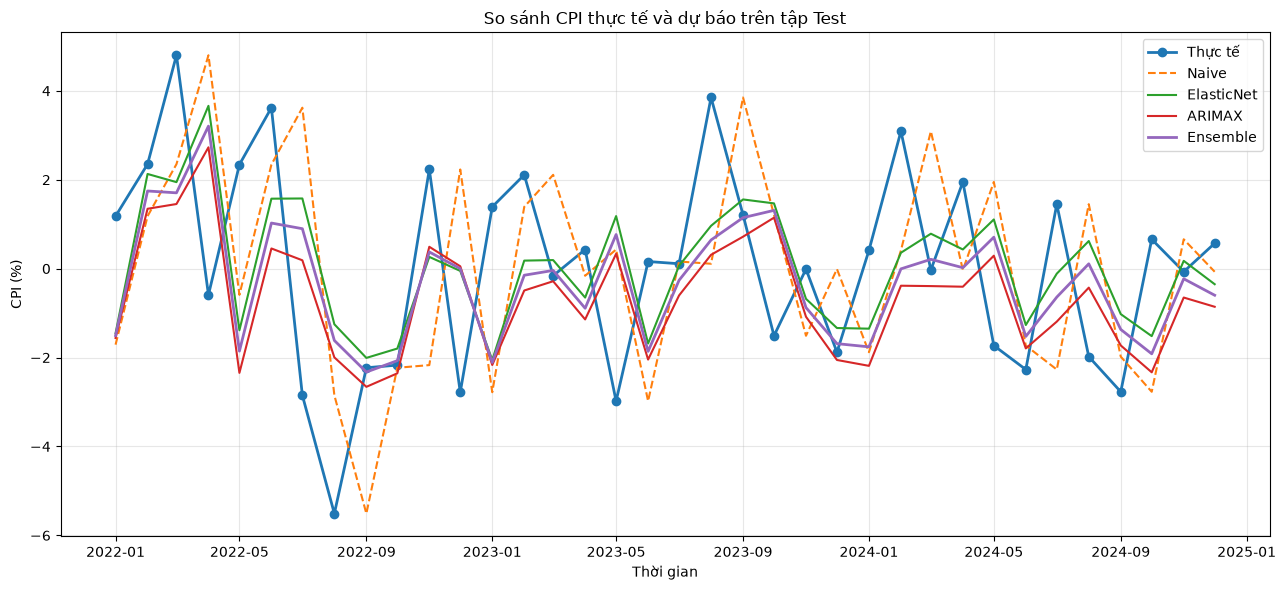

In [3]:
import matplotlib.pyplot as plt

dates = pred_df["MonthYear"].dt.to_timestamp()

plt.figure(figsize=(13, 6))

plt.plot(
    dates,
    pred_df["Actual"],
    marker="o",
    linewidth=2,
    label="Thực tế"
)

plt.plot(
    dates,
    pred_df["Naive_Pred"],
    linestyle="--",
    label="Naive"
)

plt.plot(
    dates,
    pred_df["ElasticNet_Pred"],
    label="ElasticNet"
)

plt.plot(
    dates,
    pred_df["ARIMAX_Pred"],
    label="ARIMAX"
)

plt.plot(
    dates,
    pred_df["Ensemble_Pred"],
    linewidth=2,
    label="Ensemble"
)

plt.title("So sánh CPI thực tế và dự báo trên tập Test")
plt.xlabel("Thời gian")
plt.ylabel("CPI (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Nhận xét

Biểu đồ cho thấy các mô hình nhìn chung bám được xu hướng biến động của CPI, tuy nhiên khả năng dự báo các tháng có biến động mạnh còn hạn chế.

Mô hình **Naive** thường phản ứng chậm do sử dụng CPI của tháng trước làm dự báo, vì vậy dễ bị lệch khi CPI đảo chiều đột ngột.

**ElasticNet** và **Ensemble** có đường dự báo tương đối sát nhau và nhìn chung bám CPI thực tế tốt hơn các mô hình còn lại. Tuy nhiên, hai mô hình vẫn có xu hướng làm mượt các đỉnh và đáy lớn của CPI.

**ARIMAX** cho đường dự báo ổn định hơn nhưng thường đánh giá thấp mức độ biến động thực tế tại một số thời điểm.

Nhìn chung, biểu đồ phù hợp với kết quả đánh giá định lượng trước đó, trong đó **Ensemble và ElasticNet là hai mô hình có kết quả tốt nhất trên tập Test**, nhưng vẫn còn hạn chế trong việc dự báo các cú sốc CPI lớn.

Một nguyên nhân khiến sai số dự báo tăng trong năm 2022 có thể đến từ các cú sốc kinh tế bất thường, đặc biệt là biến động mạnh của thị trường năng lượng thế giới trong giai đoạn xung đột Nga–Ukraine. Do tập Development chỉ kéo dài đến năm 2021, các mô hình chưa được quan sát trực tiếp dạng cú sốc này trong quá trình huấn luyện.

Bên cạnh đó, các biến kinh tế được sử dụng chủ yếu ở độ trễ 1 tháng nên mô hình có thể phản ứng chậm trước những biến động đột ngột xảy ra trong tháng hiện tại. Đây là một hạn chế cần được xem xét khi diễn giải kết quả dự báo giai đoạn 2022–2024.